In [1]:
%load_ext autoreload
%autoreload 2

## Generating a single SN example from ZTF SN
This notebook load a random SN and its parameters and query for the exact obs_log with correct ccd quadrants, simulate SN light curves with these parameters, and compare the sims with data.

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
RANDSEED = 42
SKY_ADU_COL = "sky_adu_ztfsn"
# SKY_ADU_COL = "sky_adu_ztfmeta"

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
import cloudpickle as pickle
from regions import RectangleSkyRegion
from astropy.coordinates import SkyCoord
import astropy.units as u
import glob
from astropy.io import fits
import sqlite3
from matplotlib.ticker import ScalarFormatter
import inspect
from IPython.display import display, Markdown

from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable, _ztfcam_ccd_gain, _ztfcam_readout_noise
from lightcurvelynx.obstable.fake_obs_table import FakeObsTable
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.pzflow_node import PZFlowNode
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.models.snia_host import SNIaHost
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.astro_utils.detector_footprint import DetectorFootprint
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding

from lightcurvelynx.graph_state import GraphState
from lightcurvelynx.simulate import compute_single_noise_free_lightcurve
from lightcurvelynx.astro_utils.noise_model import poisson_bandflux_std

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR
from lightcurvelynx.consts import GAUSS_EFF_AREA2FWHM_SQ

from utils.plotting_utils import convert_flux_to_njy, plot_coverage_map
from utils.analysis_utils import compute_sky_ztfsn_maglimit, compute_sky_ztfmeta_maglim

from ztf_snia_sim_params import SIM_PARAMS

import matplotlib

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [5]:
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

In [6]:
RNG = np.random.default_rng(RANDSEED)

In [7]:
H0 = SIM_PARAMS["H0"]
OMEGA_M = SIM_PARAMS["Omega_m"]
ALPHA = SIM_PARAMS["alpha"]
BETA = SIM_PARAMS["beta"]
MAGABS = SIM_PARAMS["mag_abs"]
SIGMA_MAGABS = SIM_PARAMS["sigma_mag_abs"]
ZP_ERR_MAG = SIM_PARAMS["zp_mag_err"]

In [8]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')
data = pd.merge(sndata,globalhostdata,on='ztfname')

In [9]:
lcdata = read_parquet('data/ztfsniadr2.parquet')

In [10]:
# randomly pick an SN in the data release to simulate
# ZTF20abegoix - this one looks good for paper
# ZTF19aazlsfj - also good
# random_sn = data.loc[data.iau_name == "2020jny"]
# random_sn = data.loc[data.ztfname == "ZTF18abebzog"]

random_sn = data.loc[data.ztfname == "ZTF20acpxvez"]
random_sn

,Unnamed: 0,ztfname,redshift,redshift_err,source,t0,x0,x1,c,t0_err,...,fitquality_flag,iau_name,frac_fitted,ra_host,dec_host,mass,mass_err,restframe_gz,restframe_gz_err,d_dlr
3420,3420,ZTF20acpxvez,0.050804,0.000012,z_gal,59177.495331,0.001516,-0.271442,-0.024812,0.100593,...,1.0,2020zko,100.0,178.072335,43.28708,9.626,0.103581,0.734697,0.019849,0.372339


In [11]:
random_lc = lcdata.loc[lcdata["ztfname"] == random_sn.ztfname.values[0]]
random_lc['lc'].iloc[0]

,mjd,filter,flux,flux_err,ZP,flag,mag,mag_err,field_id,rcid,flux_offset,offset_unc,err_scale,in_baseline
0,58131.43153,ztfg,1644.17607,1408.68056,30.0,64,99.0,99.0,714,50.0,374.1561,64.66521,1.03459,0
1,58131.44935,ztfg,2212.71428,1388.35881,30.0,64,99.0,99.0,714,50.0,374.1561,64.66521,1.03459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1626,59928.36656,ztfg,-15696.23253,37862.72938,30.0,12,99.0,99.0,714,50.0,374.1561,64.66521,1.03459,0
1627,59928.53397,ztfg,-3972.42472,1588.20604,30.0,0,99.0,99.0,714,50.0,374.1561,64.66521,1.03459,1


We first load the combined (preprocessed) obs_log and query for the overlapping entries for the specific ra/dec

In [12]:
obs_log = pd.read_parquet('data/ztf_observing_log_combined_w_metadata.parquet')
colmap = {"ra":"ra",
          "dec":"dec",
          "time":"mjd",
          "zp":"zp_nJy",
          "filter":"filter",
          "sky":"sky_adu",
         }

#ztf ccd size 6144 × 6160 pixel * 16
pixel_scale = 1.01 #arcsec/pixel
center = SkyCoord(ra=0.0, dec=0.0, unit="deg", frame="icrs")
rect_region = RectangleSkyRegion(center=center, width=7.323 * u.deg, 
                                 height=7.504 * u.deg, angle=0.0 * u.deg) # Dekany 2020 Table 3
ztf_fp = DetectorFootprint(rect_region, pixel_scale=pixel_scale)

ztf_obstable = ZTFObsTable(obs_log,colmap=colmap,detector_footprint=ztf_fp)

In [13]:
ra, dec = random_sn.ra.values[0], random_sn.dec.values[0]
idx = ztf_obstable.range_search(ra,dec)
table = ztf_obstable._table.iloc[idx]
table

,time,band,fieldid,fieldra,fielddec,rcid,maglimit,zp_abmag,gain,expid,...,obsdate,scibckgnd,ra,dec,maglim,airmass,zp,sky_adu_ztfsn,sky_adu_ztfmeta,obsmjd
25,58288.183594,ztfi,714,3.054612,0.707731,17,20.361902,25.605831,6.2,53418259,...,2018-06-19 04:22:56.500,222.75500,175.016375,40.55,19.93505,1.195,33.517827,299.650067,677.503105,58288.182598
51,58288.195312,ztfg,714,3.054612,0.707731,17,21.258118,26.235367,6.2,53419695,...,2018-06-19 04:43:37.972,82.34075,175.016375,40.55,20.67715,1.255,18.769884,200.836468,616.355366,58288.196967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521062,59272.351562,ztfi,714,3.054612,0.707731,17,19.817719,25.707018,6.5,151835150,...,2021-02-27 08:26:10.882,242.58600,175.016375,40.55,19.28965,1.014,30.535227,1409.759191,3772.228103,59272.351515
521123,59272.382812,ztfg,714,3.054612,0.707731,17,19.944382,26.373213,6.5,151838339,...,2021-02-27 09:12:05.064,92.78490,175.016375,40.55,19.42095,1.009,16.531916,3608.394101,9520.105117,59272.383392


In [14]:
obs_log_allccd = pd.read_parquet('ztfsniadr2/tables/observing_logs.parquet')
obs_log_allccd = obs_log_allccd[obs_log_allccd["expid"].isin(table.expid)]
obs_log_allccd

,mjd,band,fieldid,fieldra,fielddec,rcid,maglimit,zp,gain,expid,infobits,skynoise
1600,58288.183594,ztfi,714,3.054612,0.707731,17,20.371681,25.643682,6.2,53418259,0,25.693928
1601,58288.183594,ztfi,714,3.054612,0.707731,18,20.340397,25.674397,6.2,53418259,0,27.203817
...,...,...,...,...,...,...,...,...,...,...,...,...
32741293,59272.382812,ztfg,714,3.054612,0.707731,45,19.930592,26.373590,6.1,151838339,0,75.549141
32741294,59272.382812,ztfg,714,3.054612,0.707731,39,19.961393,26.340393,6.4,151838339,0,71.224579


In [15]:
# df1 = table
df2 = random_lc['lc'].iloc[0]
df3 = obs_log_allccd

In [16]:
# match the rcid for that sn
dflist = []
for i,row in df2.drop_duplicates(['field_id','rcid']).iterrows():
    df = df3.loc[(df3.fieldid == row['field_id']) & (df3.rcid == row['rcid'])]
    dflist.append(df)
obs_log = pd.concat(dflist)
obs_log

,mjd,band,fieldid,fieldra,fielddec,rcid,maglimit,zp,gain,expid,infobits,skynoise
1645,58288.183594,ztfi,714,3.054612,0.707731,50,20.334435,25.561434,6.2,53418259,0,24.650726
3309,58288.195312,ztfg,714,3.054612,0.707731,50,21.321350,26.293350,6.2,53419695,0,19.490816
...,...,...,...,...,...,...,...,...,...,...,...,...
32731833,59272.304688,ztfr,1754,3.194786,0.770563,29,19.929195,26.323195,6.3,151830553,0,72.215370
32731897,59272.304688,ztfr,1754,3.194786,0.770563,29,19.940420,26.289921,6.3,151830600,0,69.315483


In [17]:
con = sqlite3.connect("data/ztf_metadata_latest.db")
sql_query = "SELECT * FROM exposures"
metadata_table = pd.read_sql_query(sql_query, con)
metadata_table = metadata_table.replace("", np.nan)
metadata_table = metadata_table.dropna(subset=["fwhm"])
metadata_table.columns

Index(['expid', 'field', 'filter', 'obsdate', 'ra', 'dec', 'exptime',
       'airmass', 'infobits', 'dr', 'numsci', 'numdiff', 'fwhm', 'maglim',
       'scibckgnd', 'ellip', 'ellippa'],
      dtype='object')

In [18]:
obs_log["filter"] = obs_log.apply(lambda row: row["band"][-1],axis=1)
obs_log = pd.merge(obs_log, metadata_table[["expid","filter","exptime","fwhm","obsdate","scibckgnd","ra","dec","maglim"]],on=["filter","expid"])
gain = _ztfcam_ccd_gain
obs_log["zp_nJy"] = mag2flux(obs_log["zp"].values + 2.5*np.log10(gain))
obs_log = obs_log.rename(columns={"zp":"zp_abmag"})

In [19]:
# def compute_sky(row):
#     gain = _ztfcam_ccd_gain
#     nea = GAUSS_EFF_AREA2FWHM_SQ * (row["fwhm"]) ** 2
#     flux = np.power(10., -0.4*(row['maglim'] - row['zp_abmag'])) * gain
#     sky = (flux**2 / 25 - flux - _ztfcam_readout_noise**2 * nea) / nea / gain
#     return sky    
# The sky background is computed using the compute_sky function
display(Markdown(f"```python\n{inspect.getsource(compute_sky_ztfsn_maglimit)}\n```"))
display(Markdown(f"```python\n{inspect.getsource(compute_sky_ztfmeta_maglim)}\n```"))

```python
def compute_sky_ztfsn_maglimit(row):
    gain = _ztfcam_ccd_gain
    nea = GAUSS_EFF_AREA2FWHM_SQ * (row["fwhm"]) ** 2
    flux = np.power(10., -0.4*(row['maglimit'] - row['zp_abmag'])) * gain
    sky = (flux**2 / 25 - flux - _ztfcam_readout_noise**2 * nea) / nea / gain
    return sky    

```

```python
def compute_sky_ztfmeta_maglim(row):
    gain = _ztfcam_ccd_gain
    nea = GAUSS_EFF_AREA2FWHM_SQ * (row["fwhm"]) ** 2
    flux = np.power(10., -0.4*(row['maglim'] - row['zp_abmag'])) * gain
    sky = (flux**2 / 25 - flux - _ztfcam_readout_noise**2 * nea) / nea / gain
    return sky   

```

In [20]:
obs_log["sky_adu_ztfsn"] = obs_log.apply(compute_sky_ztfsn_maglimit,axis=1)
obs_log["sky_adu_ztfmeta"] = obs_log.apply(compute_sky_ztfmeta_maglim,axis=1)
obs_log

,mjd,band,fieldid,fieldra,fielddec,rcid,maglimit,zp_abmag,gain,expid,...,exptime,fwhm,obsdate,scibckgnd,ra,dec,maglim,zp_nJy,sky_adu_ztfsn,sky_adu_ztfmeta
0,58288.183594,ztfi,714,3.054612,0.707731,50,20.334435,25.561434,6.2,53418259,...,30.0,2.314085,2018-06-19 04:22:56.500,222.75500,175.016375,40.55,19.93505,34.916829,289.975442,622.901617
1,58288.195312,ztfg,714,3.054612,0.707731,50,21.321350,26.293350,6.2,53419695,...,30.0,2.182945,2018-06-19 04:43:37.972,82.34075,175.016375,40.55,20.67715,17.793780,198.761074,687.891869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1100,59272.304688,ztfr,1754,3.194786,0.770563,29,19.929195,26.323195,6.3,151830553,...,30.0,2.116725,2021-02-27 07:19:58.701,380.84350,183.047750,44.15,19.46225,17.311333,3138.516599,7461.349439
1101,59272.304688,ztfr,1754,3.194786,0.770563,29,19.940420,26.289921,6.3,151830600,...,30.0,2.047200,2021-02-27 07:20:39.155,380.15000,183.047750,44.15,19.50030,17.850073,3089.628337,6990.536886


In [21]:
obs_log["sky_adu"] = obs_log[SKY_ADU_COL]

In [22]:
colmap = {"ra":"ra",
          "dec":"dec",
          "time":"mjd",
          "zp":"zp_nJy",
          "filter":"filter",
          "sky":"sky_adu",
         }

#ztf ccd size 6144 × 6160 pixel * 16
pixel_scale = 1.01 #arcsec/pixel
center = SkyCoord(ra=0.0, dec=0.0, unit="deg", frame="icrs")
rect_region = RectangleSkyRegion(center=center, width=7.323 * u.deg, 
                                 height=7.504 * u.deg, angle=0.0 * u.deg) # Dekany 2020 Table 3
ztf_fp = DetectorFootprint(rect_region, pixel_scale=pixel_scale)

ztf_obstable = ZTFObsTable(obs_log,colmap=colmap,detector_footprint=ztf_fp)
ztf_obstable.survey_values["zp_err_mag"] = ZP_ERR_MAG

t_min, t_max = ztf_obstable.time_bounds()
print(f"Loaded OpSim with {len(ztf_obstable)} rows and times [{t_min}, {t_max}]")

# sky_coverage = ztf_obstable.estimate_coverage(use_footprint=True)
# print(f"The total sky coverage is {sky_coverage} square degrees")

passband_group = PassbandGroup.from_preset(preset="ZTF", filters=["g", "r", "i"])
print(f"Loaded Passbands: {passband_group}")

Loaded OpSim with 1102 rows and times [58288.18359375, 59272.3828125]
Loaded Passbands: PassbandGroup containing 3 passbands: ZTF_g, ZTF_r, ZTF_i


In [23]:
H0 = H0
Omega_m = OMEGA_M

host = SNIaHost(
    ra = random_sn.ra_host,
    dec = random_sn.dec,
    hostmass= random_sn.mass,
    redshift=random_sn.redshift,
    node_label="host",
)

In [24]:
sncosmo_modelname = "salt3"
time_extrap_before = ZeroPadding()
time_extrap_after = LinearDecayOnMag(decay_rate=0.02, mag_thres=30.)
wave_extrap_before = ZeroPadding()
wave_extrap_after = ZeroPadding()

source = SncosmoWrapperModel(
    sncosmo_modelname,
    t0=random_sn.t0.values[0],
    x0=random_sn.x0.values[0],
    x1=random_sn.x1.values[0],
    c=random_sn.c.values[0],
    ra=random_sn.ra.values[0],
    dec=random_sn.dec.values[0],
    redshift=random_sn.redshift.values[0],
    node_label="source",
    time_extrapolation=(time_extrap_before,time_extrap_after),
    wave_extrapolation=(wave_extrap_before,wave_extrap_after),   
)

mwextinction = SFDMap(
    ra=source.ra,
    dec=source.dec,
    node_label="mwext",
)

# Create an extinction effect using the EBVs from that dust map.
ext_effect = ExtinctionEffect(extinction_model="F99", ebv=mwextinction, 
                              r_v=3.1,frame='observer',backend="dust_extinction")
source.add_effect(ext_effect)


In [25]:
nsntotal = 100
lightcurves = simulate_lightcurves(source, int(nsntotal), ztf_obstable, passband_group, 
                                   obstable_save_cols=["expid","zp_nJy","scibckgnd","skynoise",
                                                       "fwhm","maglimit","maglim","sky_adu"],
                                   rng=RNG)
lightcurves

Simulating: 100%|███████████████████████████| 100/100 [00:00<00:00, 152.41obj/s]


id          ra       dec  nobs            t0         z  \
0    0  178.072566  43.28685  1102  59177.495331  0.050804   
1    1  178.072566  43.28685  1102  59177.495331  0.050804   
..  ..         ...       ...   ...           ...       ...   
98  98  178.072566  43.28685  1102  59177.495331  0.050804   
99  99  178.072566  43.28685  1102  59177.495331  0.050804   

                                               params  \
0   {'source.ra': 178.072566, 'source.dec': 43.286...   
1   {'source.ra': 178.072566, 'source.dec': 43.286...   
..                                                ...   
98  {'source.ra': 178.072566, 'source.dec': 43.286...   
99  {'source.ra': 178.072566, 'source.dec': 43.286...   

                                           lightcurve  
0   [{mjd: 58288.183594, filter: 'i', flux: 1599.3...  
1   [{mjd: 58288.183594, filter: 'i', flux: 3140.4...  
..                                                ...  
98  [{mjd: 58288.183594, filter: 'i', flux: -6158....  
99  [{mjd: 58288.183594, filter: 'i', flux: 3229.4...  

[100 rows x 8 columns]

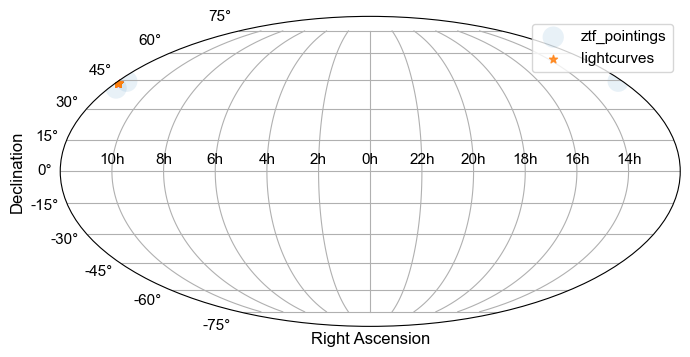

In [26]:
plot_coverage_map(ztf_obstable,lightcurves,plot_na_location=False,plot_all_location=True)

In [27]:
lightcurves = lightcurves.rename(columns={"lightcurve":"lc"})
lightcurves = lightcurves.dropna(subset="lc")

In [28]:
lightcurves['lc.snr'] = lightcurves['lc.flux']/lightcurves['lc.fluxerr']
detection_snr_thres = 5.
lightcurves['lc.detection_flag'] = lightcurves['lc.snr'] > detection_snr_thres
# drop saturation
lightcurves_after_drop_sat = lightcurves.query("lc.is_saturated==False").dropna()
# drop non detection
lightcurves_after_detection = lightcurves_after_drop_sat.query("lc.detection_flag == True").dropna()

In [29]:
def filter_flags(lc_flag, flags_to_exclude=[], flags_to_include=[]):
    pass_filter = True
    if len(flags_to_include)>0:
        pass_filter &= np.all([lc_flag & flag != 0 for flag in flags_to_include])
    if len(flags_to_exclude)>0:
        pass_filter &= np.all([lc_flag & flag == 0 for flag in flags_to_exclude])
    return pass_filter

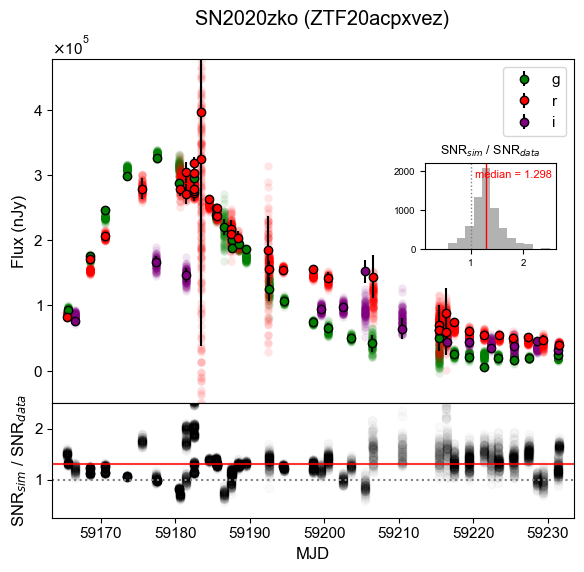

In [30]:
sncosmo_modelname = "salt3"
random_ids = lightcurves.id.sample(1).values
colormap = {'g':'g',
            'r':'r',
            'i':'purple',}

fig, (ax, ax2) = plt.subplots(2, 1,
                            gridspec_kw={'height_ratios': [3, 1]},   # top is 3x taller than bottom
                            figsize=(6, 6),sharex=True
                            )
# lc_all = lightcurves_after_detection
lc_all = lightcurves.dropna(subset=["lc"])

# state = GraphState.from_dict(lc_all.iloc[0]["params"])
# noise_free_lcs = compute_single_noise_free_lightcurve(
#     source,
#     state,
#     passband_group,
#     rest_frame_phase_min=-30.0, 
#     rest_frame_phase_max=100.0, 
#     rest_frame_phase_step=0.5, 
# )

ax = plot_lightcurves(
    fluxes=lc_all["lc.flux"],
    times=lc_all["lc.mjd"],
    filters=lc_all["lc.filter"],
    colormap=colormap,
    underlying_model=None,#noise_free_lcs,
    alpha = 0.1,
    ax = ax,
)

for line in ax.lines:
    line.set_linestyle("None")
    line.set_markeredgecolor("None")

plt.ylabel('Flux (nJy)')

lc_plot = random_lc.loc[:]
# lc_plot["lc.pass_flag_filter"] = lc_plot["lc.flag"].apply(filter_flags,flags_to_exclude=[1,2,4,8,16,32],flags_to_include=[])
# lc_plot = lc_plot.query("lc.pass_flag_filter == True")

#plot the data
lc_plot["lc.flux"], lc_plot["lc.flux_err"] = convert_flux_to_njy(lc_plot["lc.flux"],lc_plot["lc.flux_err"],zp=30.)

plot_lightcurves(
    fluxes=lc_plot["lc.flux"],
    times=lc_plot["lc.mjd"],
    fluxerrs=lc_plot["lc.flux_err"],
    filters=[x[-1] for x in lc_plot["lc.filter"]],
    colormap=colormap,
    ax = ax,
    marker = 'o',
    markeredgecolor= "k",
    ecolor="k",
)

t_plot_min, t_plot_max = np.max([random_sn.t0.values[0] - 20*(1+random_sn.redshift.values[0]),t_min])+7, np.min([random_sn.t0.values[0] + 60*(1+random_sn.redshift.values[0]),t_max])-7
plt.xlim((t_plot_min,t_plot_max))
ax.set_xlabel('')
ax.set_ylim((-5e4,mag2flux(17.2)))
plt.tight_layout()
plt.suptitle(f"SN{random_sn.iau_name.values[0]} ({random_sn.ztfname.values[0]})",y=0.95,x=0.55)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((0,0))  # force scientific
fmt.set_scientific(True)
handles, labels = ax.get_legend_handles_labels()
labels[3:] = ["g", "i", "r"]
order = [0, 2, 1]   # new order of indexes
ax.legend([handles[3:][i] for i in order], 
          [labels[3:][i] for i in order],loc="upper right")


ax.yaxis.set_major_formatter(fmt)
ztf_lc = lc_plot['lc'].iloc[0]

snr_ratio_all=[]
for i in range(0,len(lightcurves)):
    lynx_lc = lc_all.query(f"lc.mjd > {t_plot_min} & lc.mjd < {t_plot_max}")["lc"].iloc[i]
    
    merged = pd.merge_asof(
        lynx_lc.sort_values('mjd'),
        ztf_lc.sort_values('mjd'),
        on='mjd',
        direction='nearest',
        tolerance=0.01,
        suffixes = ('_lynx','_ztf'),
    )
    merged = merged.dropna().loc[merged.dropna().detection_flag]
    # ax2.plot(merged.mjd,(merged.flux_lynx/merged.fluxerr)/(merged.flux_ztf/merged.flux_err),'o',color='k',alpha=0.02,)
    ratio = (merged.flux_lynx/merged.fluxerr) / (merged.flux_ztf/merged.flux_err)
    snr_ratio_all.extend(ratio.to_numpy())
    ax2.plot(merged.mjd, ratio, 'o', color='k', alpha=0.02)

plt.ylim((0.25,2.5))
med = np.median(snr_ratio_all)
plt.axhline(y=1,ls=':',color='gray')
plt.axhline(y=med,ls='-',color='red',alpha=0.8)
plt.xlabel('MJD')
plt.ylabel(r"SNR$_{sim}$ / SNR$_{data}$")

# --- prepare data ---
snr_ratio_all = np.asarray(snr_ratio_all)
snr_ratio_all = snr_ratio_all[np.isfinite(snr_ratio_all)]

# --- inset histogram INSIDE main panel ---
axh = inset_axes(
    ax,                      # ← attach to MAIN panel
    width="25%",
    height="25%",
    loc="upper right",
    bbox_to_anchor=(0, -0.25, 1, 1),  # ← move DOWN (tune this)
    bbox_transform=ax.transAxes,
    borderpad=1.2,
)

ymin, ymax = ax2.get_ylim()
axh.hist(
    snr_ratio_all,
    bins=np.linspace(ymin, ymax, 15),
    histtype="stepfilled",
    alpha=0.3,
    color='k',
)

# reference + median
axh.axvline(1, ls=":", color="gray", lw=1)
axh.axvline(med, color="red", lw=1)

axh.text(
    0.97, 0.92,
    f"median = {med:.3f}",
    transform=axh.transAxes,
    ha="right",
    va="top",
    fontsize=8,
    color="red",
)

# clean look
axh.set_title(r"SNR$_{sim}$ / SNR$_{data}$", fontsize=9)
axh.tick_params(labelsize=7)

fig.tight_layout()
fig.subplots_adjust(hspace=0)

plt.savefig("paper_figs/example_lc.png", dpi=300, bbox_inches='tight')

In [31]:
t_min = t_plot_min
t_max = t_plot_max

In [32]:
lynx_lc = lc_all.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]
ztf_lc = lc_plot.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]

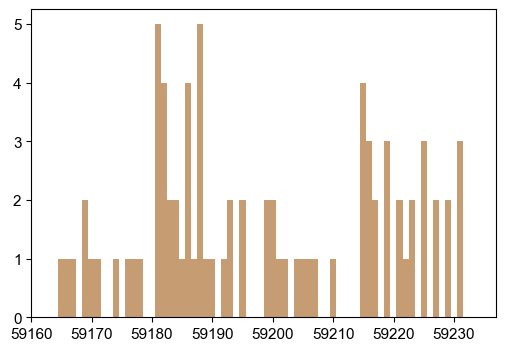

In [33]:
bins = np.arange(t_min,t_max,1)
plt.hist(lynx_lc.mjd,bins=bins,alpha=0.5)
plt.hist(ztf_lc.mjd,bins=bins,alpha=0.5)
plt.show()

In [34]:
from astropy.time import Time
t = Time([t_min,t_max], format='mjd', scale='utc')
t.to_datetime()

array([datetime.datetime(2020, 11, 10, 11, 30, 6, 800006),
       datetime.datetime(2021, 1, 19, 13, 2, 45, 983366)], dtype=object)

Median flux ratio: 0.9900474145755851


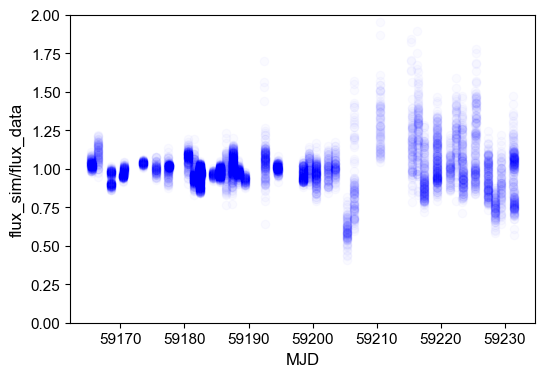

In [35]:
ztf_lc = lc_plot.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]

all_flux_ratio = []
for i in range(0,len(lightcurves)):
    lynx_lc = lc_all.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[i]
    
    merged = pd.merge_asof(
        lynx_lc.sort_values('mjd'),
        ztf_lc.sort_values('mjd'),
        on='mjd',
        direction='nearest',
        tolerance=0.01,
        suffixes = ('_lynx','_ztf'),
    )
    merged = merged.dropna().loc[merged.dropna().detection_flag]
    ratio = merged.flux_lynx/merged.flux_ztf
    plt.plot(merged.mjd,ratio,'o',alpha=0.02,color='b')
    all_flux_ratio.extend(ratio.to_numpy())

plt.ylim((0,2))
plt.xlabel('MJD')
plt.ylabel("flux_sim/flux_data")
print("Median flux ratio:", np.median(all_flux_ratio))

Median flux error ratio: 0.7623955027313835


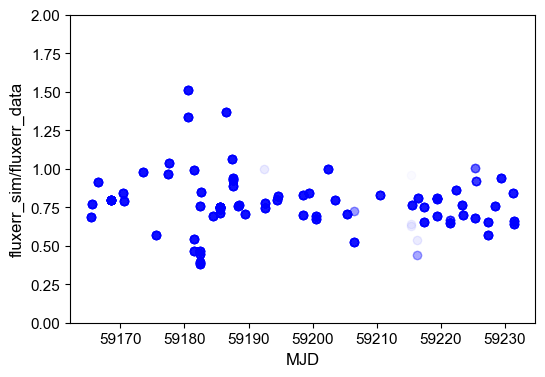

In [36]:
ztf_lc = lc_plot.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]

all_fluxerr_ratio = []
for i in range(0,len(lightcurves)):
    lynx_lc = lc_all.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[i]
    
    merged = pd.merge_asof(
        lynx_lc.sort_values('mjd'),
        ztf_lc.sort_values('mjd'),
        on='mjd',
        direction='nearest',
        tolerance=0.01,
        suffixes = ('_lynx','_ztf'),
    )
    merged = merged.dropna().loc[merged.dropna().detection_flag]
    ratio = merged.fluxerr/merged.flux_err
    plt.plot(merged.mjd,ratio,'o',color='b',alpha=0.02)
    all_fluxerr_ratio.extend(ratio.to_numpy())
    
plt.ylim((0.,2))
plt.xlabel('MJD')
plt.ylabel("fluxerr_sim/fluxerr_data")
print("Median flux error ratio:", np.median(all_fluxerr_ratio))

Median snr ratio: 1.2981947169783155


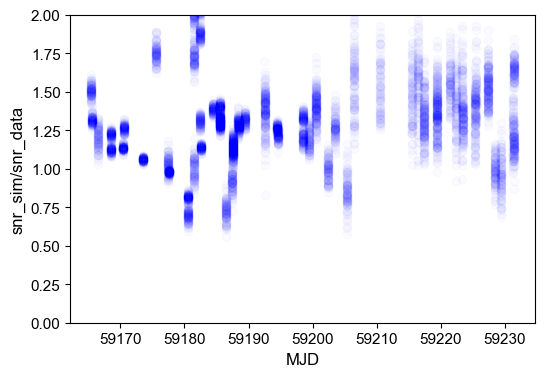

In [37]:
ztf_lc = lc_plot.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]

all_snr_ratio = []
for i in range(0,len(lightcurves)):
    lynx_lc = lc_all.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[i]
    
    merged = pd.merge_asof(
        lynx_lc.sort_values('mjd'),
        ztf_lc.sort_values('mjd'),
        on='mjd',
        direction='nearest',
        tolerance=0.01,
        suffixes = ('_lynx','_ztf'),
    )
    merged = merged.dropna().loc[merged.dropna().detection_flag]
    ratio = (merged.flux_lynx/merged.fluxerr)/(merged.flux_ztf/merged.flux_err)
    plt.plot(merged.mjd,ratio,'o',color='b',alpha=0.02)
    all_snr_ratio.extend(ratio.to_numpy())

plt.ylim((0,2))
plt.xlabel('MJD')
plt.ylabel("snr_sim/snr_data")
print("Median snr ratio:", np.median(all_snr_ratio))

random idx= 31


Text(0, 0.5, 'Number Density')

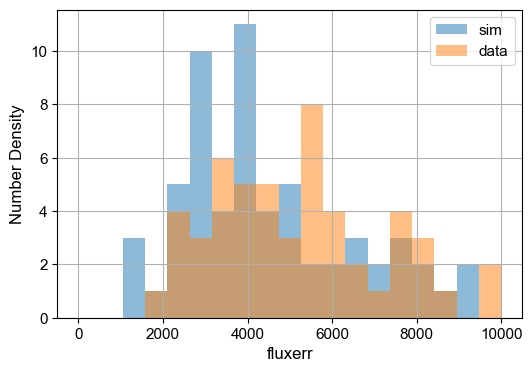

In [38]:
ztf_lc = lc_plot.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]

idx = np.random.randint(len(lightcurves))
print("random idx=",idx)
lynx_lc = lc_all.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[i]

merged = pd.merge_asof(
    lynx_lc.sort_values('mjd'),
    ztf_lc.sort_values('mjd'),
    on='mjd',
    direction='nearest',
    tolerance=0.01,
    suffixes = ('_lynx','_ztf'),
)
merged = merged.dropna().loc[merged.dropna().detection_flag]
(merged.fluxerr).hist(bins=np.linspace(0,1e4,20),alpha=0.5,label='sim')
(merged.flux_err).hist(bins=np.linspace(0,1e4,20),alpha=0.5,label='data')
plt.legend()
# plt.ylim((0,5))
plt.xlabel('fluxerr')
plt.ylabel("Number Density")
